# 제주 특산물 가격 예측 - 통합 데이터 전처리 및 EDA 🍊
본 노트북은 기본 환경 설정, 데이터 탐색(EDA), 그리고 모델 학습을 위한 파생 변수 생성(Feature Engineering)을 한 번에 수행하는 통합 파이프라인입니다.

In [2]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# OS별 한글 폰트 자동 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ 라이브러리 로드 및 한글 폰트 설정 완료")

✅ 라이브러리 로드 및 한글 폰트 설정 완료


## 1. 데이터 로드 및 컬럼명 최적화
경로 오류를 방지하기 위해 파일 위치를 자동으로 찾는 함수를 적용하고, 다루기 편하도록 타겟 변수의 이름을 직관적으로 변경합니다.

In [3]:
def smart_load(file_name):
    # 여러 경로를 탐색하여 데이터 로드
    paths = [file_name, f"data/{file_name}", f"../data/{file_name}"]
    for p in paths:
        if os.path.exists(p):
            # utf-8-sig 인코딩으로 한글 깨짐 방지
            return pd.read_csv(p, encoding='utf-8-sig')
    print(f"❌ {file_name} 파일을 찾을 수 없습니다.")
    return None

train_df = smart_load('train.csv')
test_df = smart_load('test.csv')

# 컬럼명 단순화 (코딩 편의성 증대)
if train_df is not None:
    train_df.rename(columns={'supply(kg)':'supply', 'price(원/kg)':'price'}, inplace=True)
if test_df is not None:
    test_df.rename(columns={'supply(kg)':'supply', 'price(원/kg)':'price'}, inplace=True)

print(f"✅ Train 데이터 형태: {train_df.shape}")
print(f"✅ Test 데이터 형태: {test_df.shape}")

✅ Train 데이터 형태: (59397, 7)
✅ Test 데이터 형태: (1092, 5)


## 2. 데이터 탐색 (EDA) 및 이상치 검증
수치형 데이터의 통계량과, 실질적인 결측치 역할을 하는 '0값(휴장일 등)'의 비중을 확인합니다.

In [4]:
print('=== Train 데이터 상위 5행 ===')
display(train_df.head())

print('\n=== 수치형 변수 기초 통계 ===')
display(train_df.describe())

# 0값(거래 없음)을 실질적 결측치(휴장일)로 판단하여 비중 확인
train_df['is_zero'] = (train_df['price'] == 0) & (train_df['supply'] == 0)
zero_ratio = train_df['is_zero'].mean() * 100
print(f"\n🔍 전체 데이터 중 가격과 물량이 모두 0인 데이터 비율: {zero_ratio:.2f}%")

=== Train 데이터 상위 5행 ===


,ID,timestamp,item,corporation,location,supply,price
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0
3,TG_A_J_20190104,2019-01-04,TG,A,J,25000.0,1408.0
4,TG_A_J_20190105,2019-01-05,TG,A,J,32352.0,1250.0



=== 수치형 변수 기초 통계 ===


,supply,price
count,5.939700e+04,59397.000000
mean,1.189453e+04,1131.680674
std,5.226400e+04,2029.941445
min,0.000000e+00,0.000000
25%,0.000000e+00,0.000000
50%,0.000000e+00,0.000000
75%,3.800000e+03,1519.000000
max,1.222800e+06,20909.000000



🔍 전체 데이터 중 가격과 물량이 모두 0인 데이터 비율: 59.69%


## 3. 피처 엔지니어링 (Feature Engineering)
시계열 예측 모델의 성능을 높이기 위해 다음 피처들을 일괄 생성합니다.
1. **날짜 정보**: 연, 월, 일, 요일, 계절
2. **공휴일 정보**: 한국 법정 공휴일 여부 (`holidays` 라이브러리 활용)
3. **순환형 인코딩**: 모델이 12월과 1월이 이어져 있음을 학습하도록 요일과 월에 `sin/cos` 변환 적용

In [5]:
# 날짜 타입으로 변환
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])

def create_features(df):
    df_feat = df.copy()
    
    # 1. 기본 날짜 피처
    df_feat['year'] = df_feat['timestamp'].dt.year
    df_feat['month'] = df_feat['timestamp'].dt.month
    df_feat['day'] = df_feat['timestamp'].dt.day
    df_feat['dow'] = df_feat['timestamp'].dt.dayofweek # 0:월요일 ~ 6:일요일
    
    # 2. 계절 피처
    def get_season(month):
        if month in [12, 1, 2]: return 1 # 겨울
        elif month in [3, 4, 5]: return 2 # 봄
        elif month in [6, 7, 8]: return 3 # 여름
        else: return 4 # 가을
    df_feat['season'] = df_feat['month'].apply(get_season)
    
    # 3. 공휴일 피처
    kr_holidays = holidays.KR()
    df_feat['is_holiday'] = df_feat['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
    
    # 4. 시계열 순환(Cyclical) 인코딩 (신경망 모델 등에 매우 유용)
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)
    df_feat['dow_sin'] = np.sin(2 * np.pi * df_feat['dow'] / 7)
    df_feat['dow_cos'] = np.cos(2 * np.pi * df_feat['dow'] / 7)
    
    return df_feat

train_processed = create_features(train_df)
test_processed = create_features(test_df)

print("✅ 피처 엔지니어링 완료! 추가된 컬럼 샘플:")
display(train_processed[['timestamp', 'year', 'month', 'season', 'is_holiday', 'month_sin', 'dow_cos']].head())

✅ 피처 엔지니어링 완료! 추가된 컬럼 샘플:


,timestamp,year,month,season,is_holiday,month_sin,dow_cos
0,2019-01-01,2019,1,1,1,0.5,0.623490
1,2019-01-02,2019,1,1,0,0.5,-0.222521
2,2019-01-03,2019,1,1,0,0.5,-0.900969
3,2019-01-04,2019,1,1,0,0.5,-0.900969
4,2019-01-05,2019,1,1,0,0.5,-0.222521


# 제주 특산물 가격 예측 - 통합 시각화 및 전처리 🍊
본 노트북은 팀원들과 인사이트를 도출하기 위한 **풍부한 시각적 탐색(EDA)**과 전처리 코드를 포함하고 있습니다.

In [6]:
# holidays 라이브러리 설치 (없는 경우를 대비)
#!pip install holidays -q

import os
import pandas as pd
import numpy as np
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings
warnings.filterwarnings("ignore")

# 폰트 설정 (Mac, Windows, Linux 완벽 대응)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
print("✅ 환경 설정 및 폰트 로드 완료")

✅ 환경 설정 및 폰트 로드 완료


## 1. 데이터 로드 및 기본 전처리
데이터를 불러오고, 다루기 쉽도록 컬럼명을 변경한 뒤 휴장일(0원, 0kg) 데이터를 마킹합니다.

In [7]:
# train.csv 파일 로드 (경로가 다르면 파일명을 수정해주세요)
train_df = pd.read_csv('train.csv')
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])

# 다루기 쉽게 컬럼명 변경
train_df.rename(columns={'supply(kg)':'supply', 'price(원/kg)':'price'}, inplace=True)

# 가격과 물량이 0인 날짜 마킹 및 요일 추출
train_df['is_zero'] = (train_df['price'] == 0) & (train_df['supply'] == 0)
train_df['day_name'] = train_df['timestamp'].dt.day_name()

print(f"✅ 데이터 크기: {train_df.shape}")
display(train_df.head(3))

✅ 데이터 크기: (59397, 9)


,ID,timestamp,item,corporation,location,supply,price,is_zero,day_name
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0,True,Tuesday
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0,True,Wednesday
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0,False,Thursday


## 2. 시각적 데이터 탐색 (EDA)
### 📊 2-1. 타겟 변수(가격) 분포 확인
0원이 포함된 전체 분포와, 0원을 제외한 실제 거래 가격의 분포를 비교합니다.

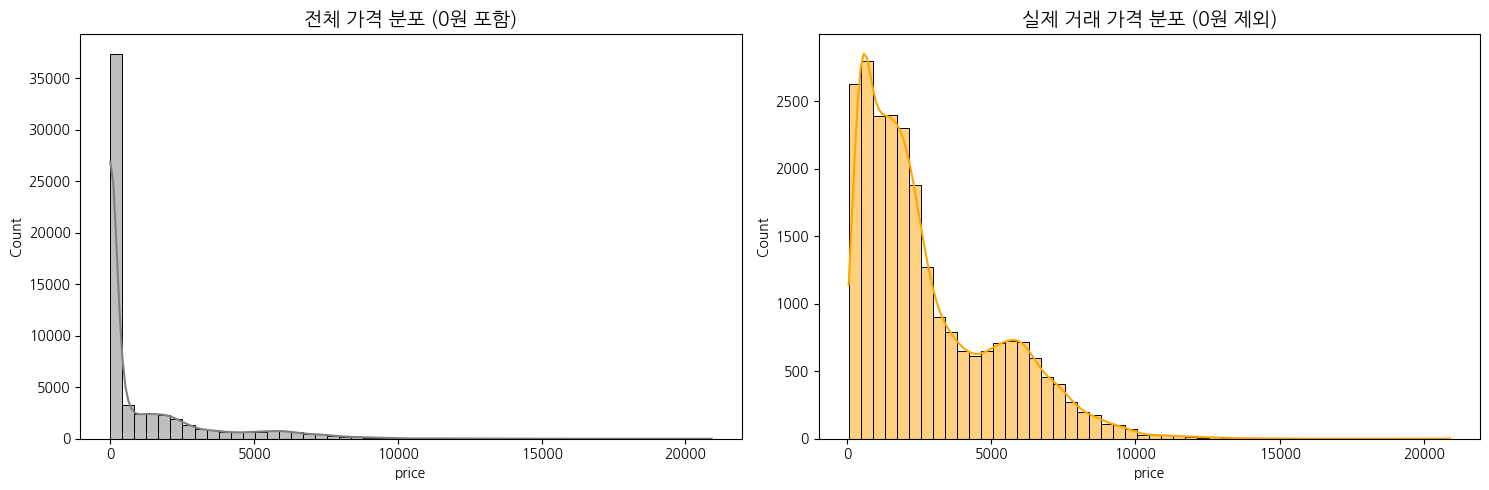

In [8]:
plt.figure(figsize=(15, 5))

# 왼쪽: 0원 포함
plt.subplot(1, 2, 1)
sns.histplot(train_df['price'], bins=50, kde=True, color='gray')
plt.title('전체 가격 분포 (0원 포함)', fontsize=14)

# 오른쪽: 0원 제외 (실제 거래 가격)
plt.subplot(1, 2, 2)
sns.histplot(train_df[train_df['price'] > 0]['price'], bins=50, kde=True, color='orange')
plt.title('실제 거래 가격 분포 (0원 제외)', fontsize=14)

plt.tight_layout()
plt.show()

### 📊 2-2. 품목별 시계열 가격 추이 (7일 이동평균)
노이즈를 줄이고 가격 추세를 명확히 보기 위해 7일 이동평균선(Rolling Mean)을 그립니다.

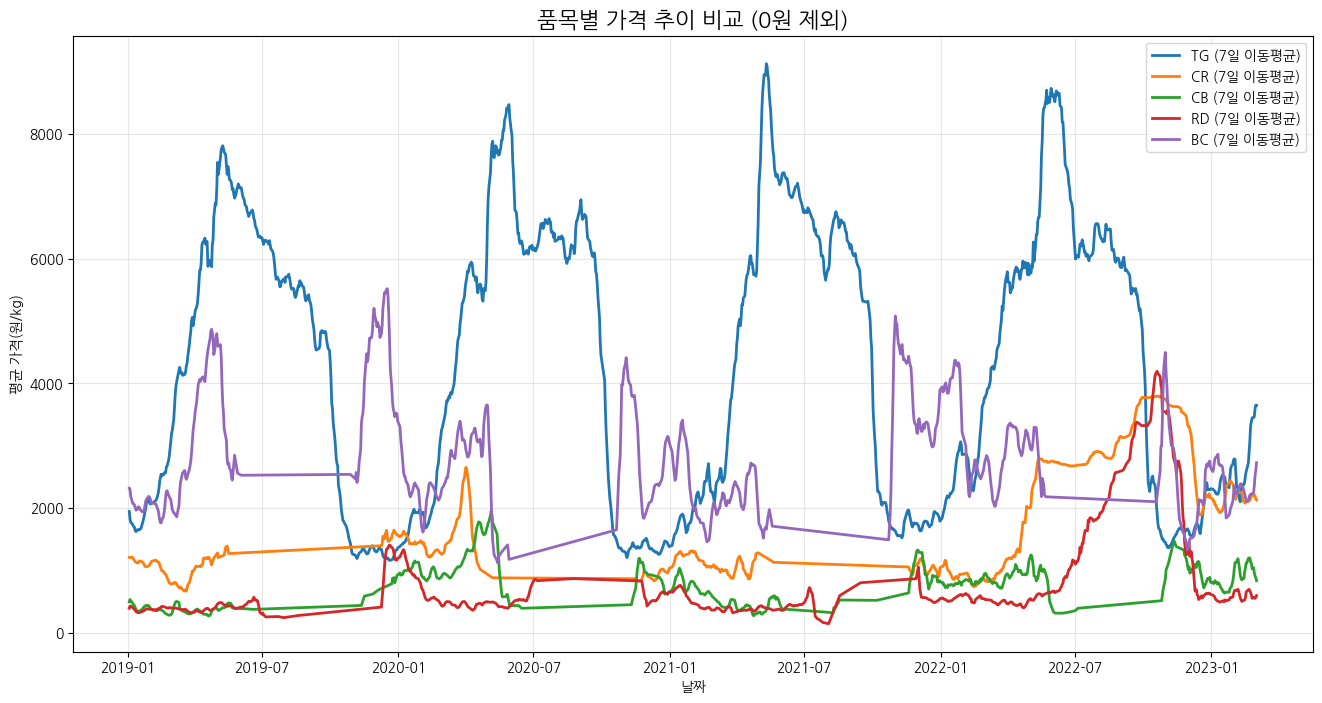

In [9]:
plt.figure(figsize=(16, 8))
items = train_df['item'].unique()

for item in items:
    # 0원 거래 제외 및 품목별 필터링
    temp = train_df[(train_df['item'] == item) & (train_df['price'] > 0)]
    daily_mean = temp.groupby('timestamp')['price'].mean()
    
    # 7일 이동평균선 시각화
    rolling_mean = daily_mean.rolling(window=7, min_periods=1).mean()
    plt.plot(rolling_mean.index, rolling_mean.values, label=f'{item} (7일 이동평균)', linewidth=2)

plt.title('품목별 가격 추이 비교 (0원 제외)', fontsize=16)
plt.xlabel('날짜')
plt.ylabel('평균 가격(원/kg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

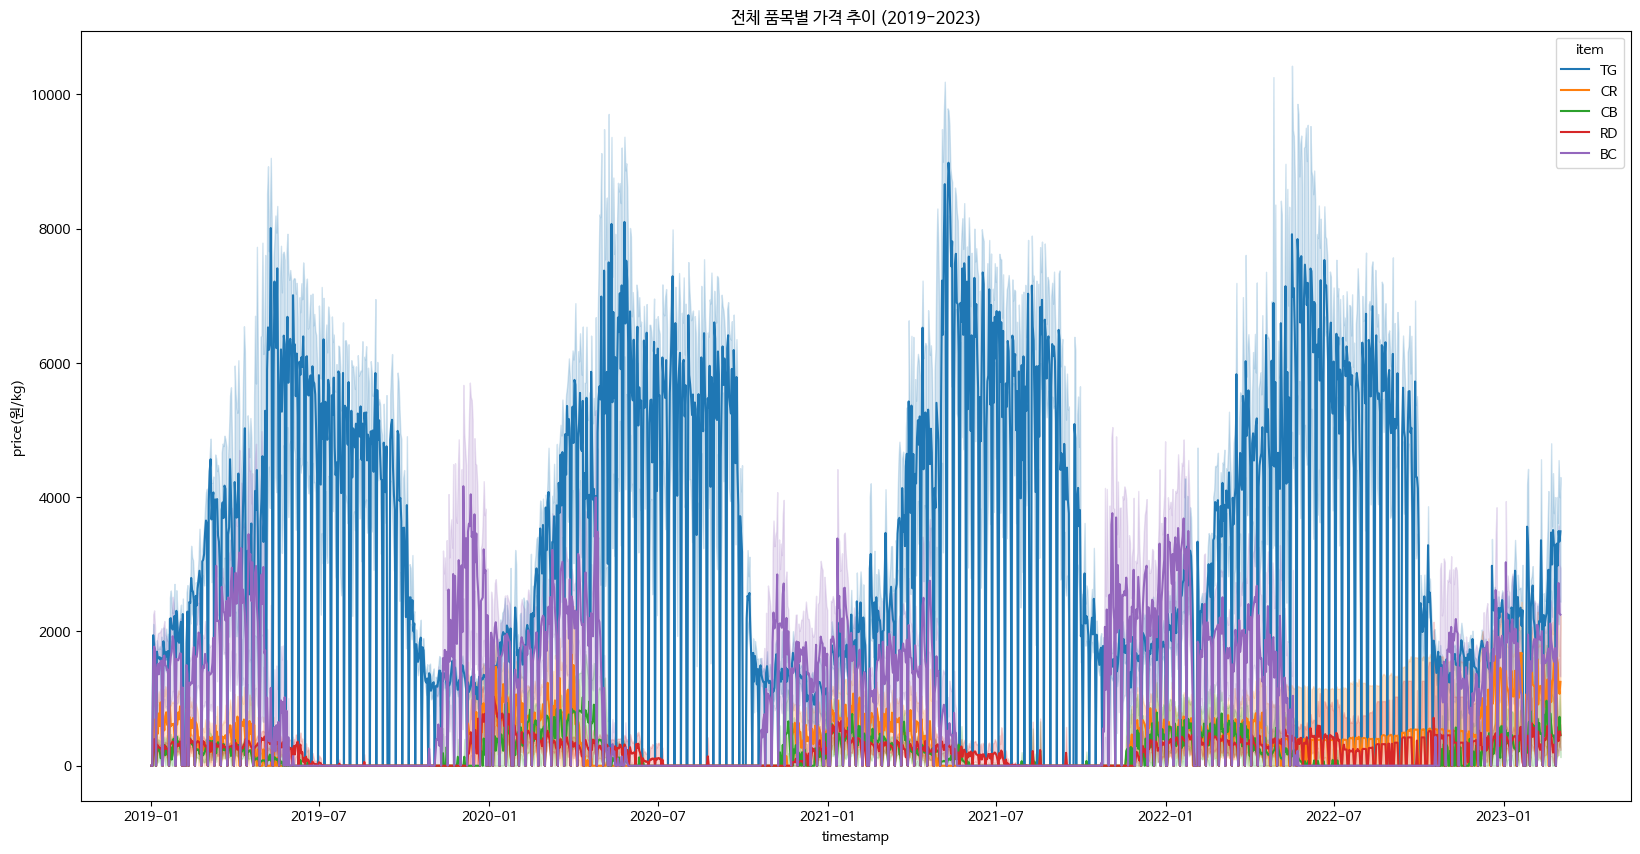

In [47]:
# 품목별 전체 시계열 추이
plt.figure(figsize=(20, 10))
sns.lineplot(data=train, x="timestamp", y="price(원/kg)", hue="item")
plt.title("전체 품목별 가격 추이 (2019-2023)")
plt.show()

### 📊 2-3. 요일별 휴장(0값) 비중 시각화
어떤 요일에 거래가 멈추는지 직관적으로 확인합니다.

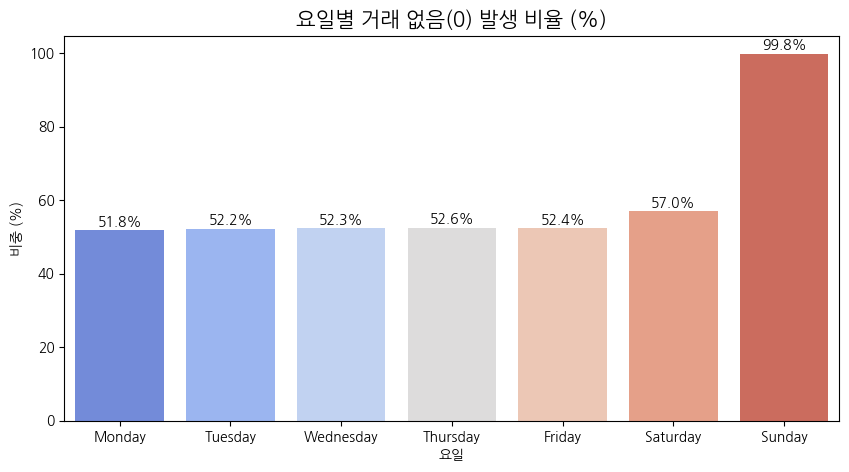

In [10]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_zero = train_df.groupby('day_name')['is_zero'].mean().reindex(day_order).reset_index()
dow_zero['is_zero'] = dow_zero['is_zero'] * 100

plt.figure(figsize=(10, 5))
sns.barplot(data=dow_zero, x='day_name', y='is_zero', hue='day_name', palette='coolwarm', legend=False)
plt.title('요일별 거래 없음(0) 발생 비율 (%)', fontsize=15)
plt.ylabel('비중 (%)')
plt.xlabel('요일')

for i, v in enumerate(dow_zero['is_zero']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.show()

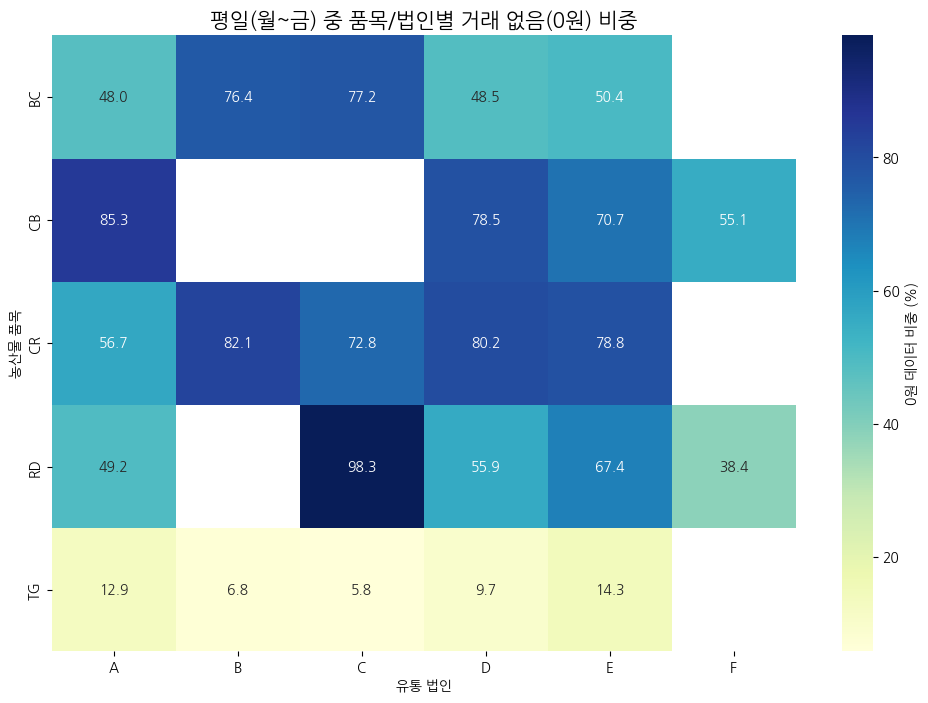

💡 인사이트: 특정 법인(예: RD-C)은 평일에도 거의 거래가 없어 0원 비중이 98%에 달합니다. 
이러한 조합들이 모여 전체 평일 평균 52%라는 수치를 만듭니다.


In [11]:
# 평일(월-금) 데이터만 추출
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
df_weekday = train_df[train_df['day_name'].isin(weekdays)]

# 품목(item)과 법인(corporation)별로 0원 데이터 비중 계산
zero_matrix = df_weekday.groupby(['item', 'corporation'])['is_zero'].mean().unstack() * 100

plt.figure(figsize=(12, 8))
sns.heatmap(zero_matrix, annot=True, fmt=".1f", cmap='YlGnBu', cbar_kws={'label': '0원 데이터 비중 (%)'})
plt.title('평일(월~금) 중 품목/법인별 거래 없음(0원) 비중', fontsize=15)
plt.xlabel('유통 법인')
plt.ylabel('농산물 품목')
plt.show()

print("💡 인사이트: 특정 법인(예: RD-C)은 평일에도 거의 거래가 없어 0원 비중이 98%에 달합니다. \n이러한 조합들이 모여 전체 평일 평균 52%라는 수치를 만듭니다.")

## 특정 유통법인 심층 분석 (Case Study)
특정 법인(예: **A법인**)의 품목별 가격 패턴을 분석합니다. 법인 내에서 품목별로 경매가 어떻게 이루어지는지, 가격의 고점과 저점은 언제인지 확인합니다.

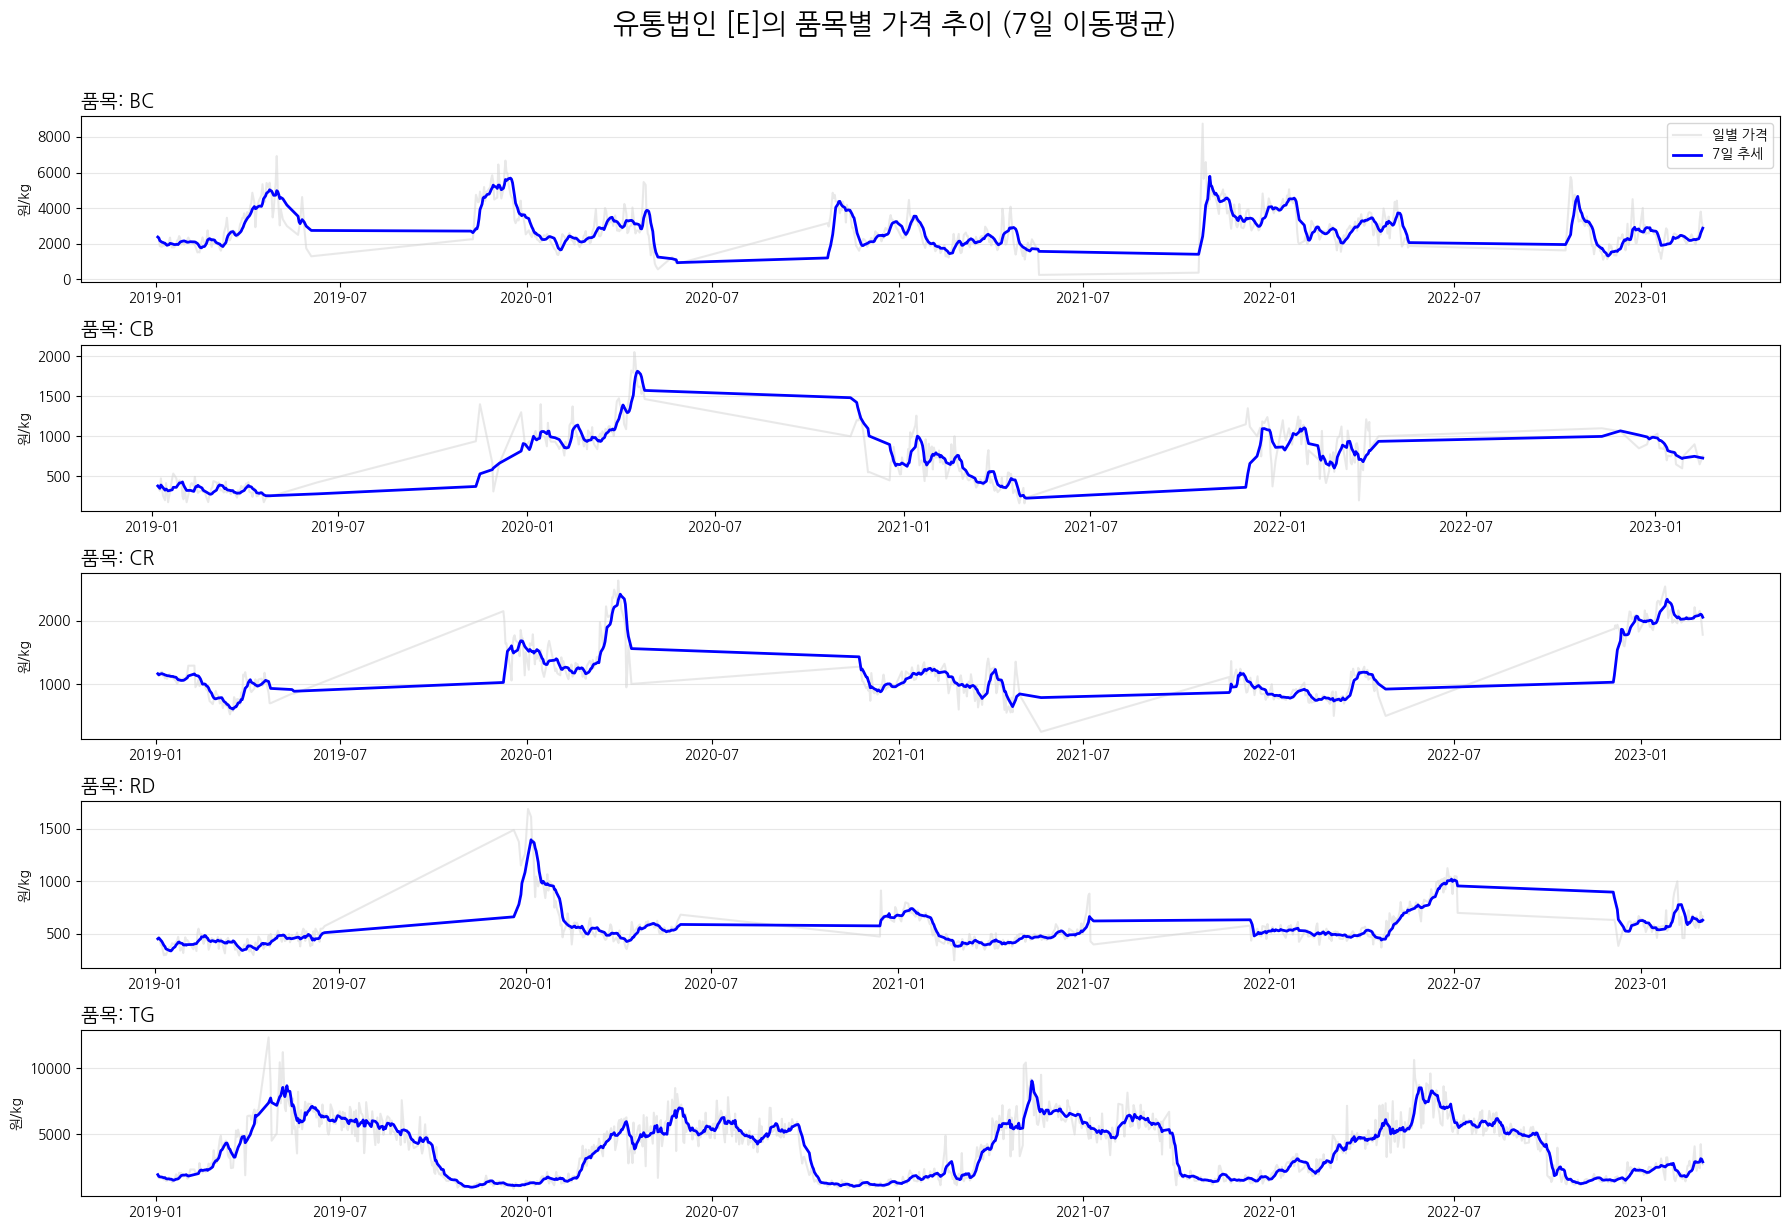

--- [E 법인] 품목별 실제 거래 가격 통계 ---


,count,mean,std,min,25%,50%,75%,max
item,,,,,,,,
BC,1296.0,2852.4,1049.8,250.0,2108.0,2616.5,3419.2,8750.0
CB,376.0,754.4,370.5,163.0,422.5,750.0,1000.0,2051.0
CR,513.0,1216.4,456.1,250.0,878.0,1099.0,1398.0,2629.0
RD,788.0,543.0,178.2,200.0,435.8,500.0,596.0,1687.0
TG,2225.0,3629.2,2248.0,585.0,1589.0,3106.0,5404.0,12333.0


In [12]:
# 분석하고 싶은 법인을 지정하세요 (A, B, C, D, E, F 중 선택)
target_corp = 'E'

# 해당 법인의 데이터만 필터링 (실제 거래가 있는 데이터만)
corp_df = train_df[(train_df['corporation'] == target_corp) & (train_df['price'] > 0)]

# 품목 리스트 추출
corp_items = corp_df['item'].unique()

plt.figure(figsize=(18, 12))
plt.suptitle(f'유통법인 [{target_corp}]의 품목별 가격 추이 (7일 이동평균)', fontsize=20, y=1.02)

for i, item in enumerate(sorted(corp_items), 1):
    plt.subplot(len(corp_items), 1, i)
    
    # 품목별 데이터 추출
    item_data = corp_df[corp_df['item'] == item].groupby('timestamp')['price'].mean().reset_index()
    
    # 이동평균 계산 (추세선)
    item_data['rolling_7'] = item_data['price'].rolling(window=7, min_periods=1).mean()
    
    # 시각화
    plt.plot(item_data['timestamp'], item_data['price'], color='lightgray', alpha=0.5, label='일별 가격')
    plt.plot(item_data['timestamp'], item_data['rolling_7'], color='blue', linewidth=2, label='7일 추세')
    
    plt.title(f'품목: {item}', fontsize=14, loc='left')
    plt.ylabel('원/kg')
    if i == 1:
        plt.legend(loc='upper right')
    plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 해당 법인의 품목별 기초 통계량 출력
print(f"--- [{target_corp} 법인] 품목별 실제 거래 가격 통계 ---")
display(corp_df.groupby('item')['price'].describe().round(1))

## 법인별 취급 품목 분석 (Portfolio Analysis)
모든 법인이 모든 농산물을 취급하지 않습니다. 법인별로 어떤 품목에 집중하고 있는지, 혹은 아예 취급하지 않는 품목은 무엇인지 분석하여 데이터의 '0'값이 갖는 의미를 파악합니다.

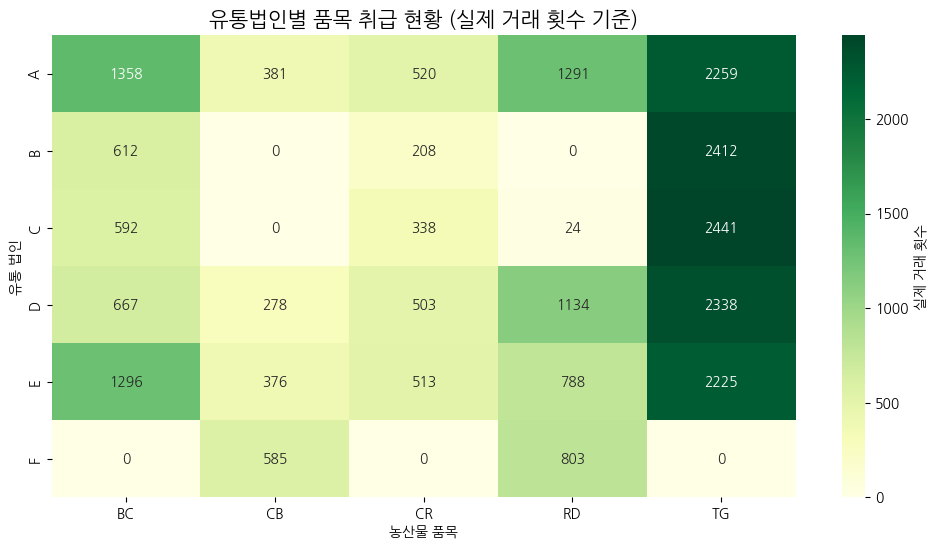

--- 법인별 취급 품목 개수 ---
corporation
A    5
D    5
E    5
C    4
B    3
F    2
dtype: int64


In [13]:
# 1. 법인별/품목별 데이터 개수(거래 빈도) 계산
# 실제 가격이 0보다 큰(거래가 발생한) 데이터만 카운트합니다.
active_trade = train_df[train_df['price'] > 0].groupby(['corporation', 'item']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(active_trade, annot=True, fmt='d', cmap='YlGn', cbar_kws={'label': '실제 거래 횟수'})
plt.title('유통법인별 품목 취급 현황 (실제 거래 횟수 기준)', fontsize=15)
plt.xlabel('농산물 품목')
plt.ylabel('유통 법인')
plt.show()

# 2. 법인별 취급 품목 수 출력
item_counts = active_trade.astype(bool).sum(axis=1)
print("--- 법인별 취급 품목 개수 ---")
print(item_counts.sort_values(ascending=False))

데이터에서 발견할 수 있는 사실 (인사이트)
1. 백화점형 법인 vs 전문형 법인: 어떤 법인은 5개 품목을 골고루 다 다루지만, 어떤 법인은 특정 품목(예: 감귤만 전문으로) 1~2개만 집중적으로 취급합니다.

2. 데이터의 '0'은 결측치가 아니다: 특정 법인에서 특정 품목의 거래 횟수가 0이라면, 그건 데이터가 누락된 게 아니라 **"그 법인은 그 물건을 팔지 않는다"**는 아주 중요한 정보입니다.

3. 예측 전략: 만약 테스트 데이터(test.csv)에서 **'C법인이 브로콜리를 판다'**는 조합이 나왔는데, 위 표에서 그 값이 0이라면 우리는 고민 없이 0원으로 예측값을 던질 수 있습니다.

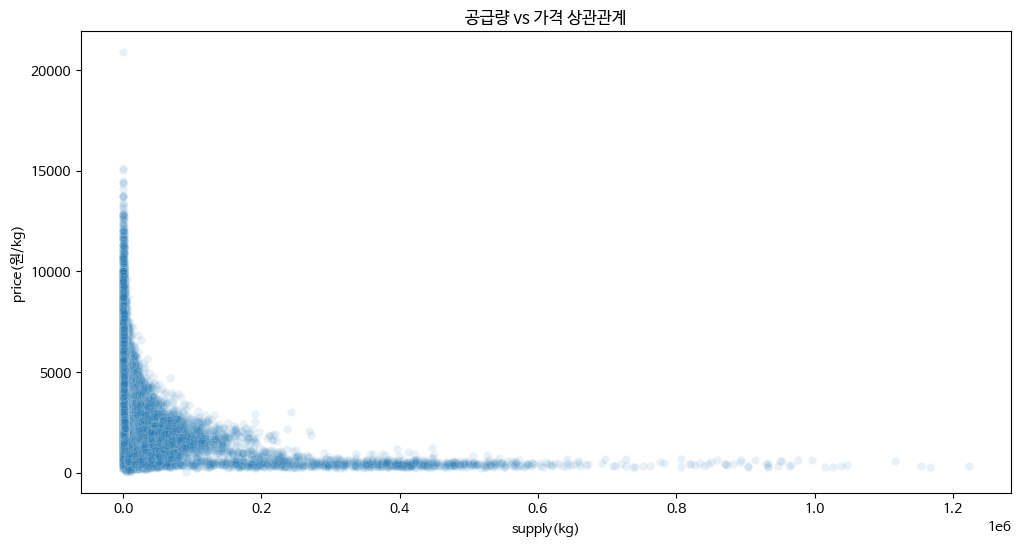

In [46]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=train[train["price(원/kg)"]>0], x="supply(kg)", y="price(원/kg)", alpha=0.1)
plt.title("공급량 vs 가격 상관관계")
plt.show()

설정된 폰트: NanumBarunGothic


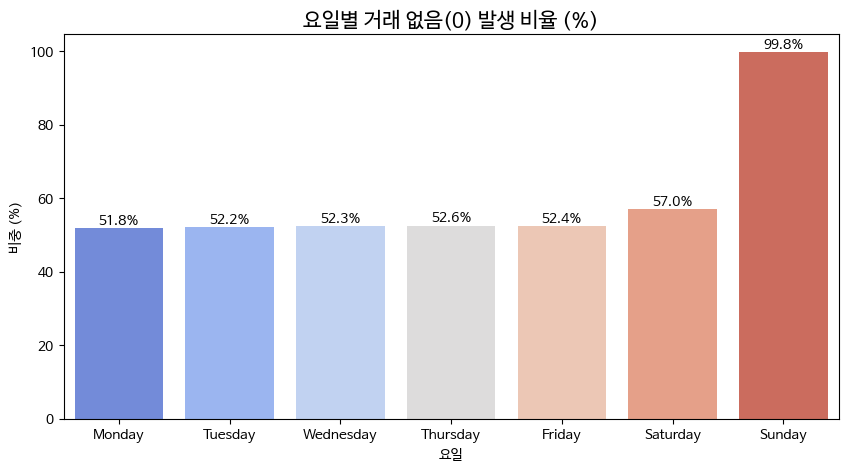

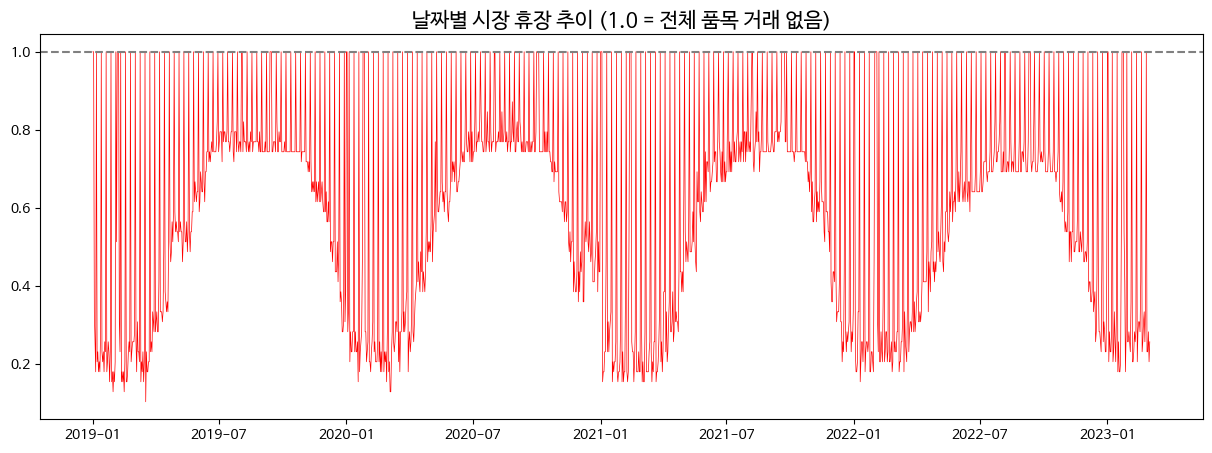

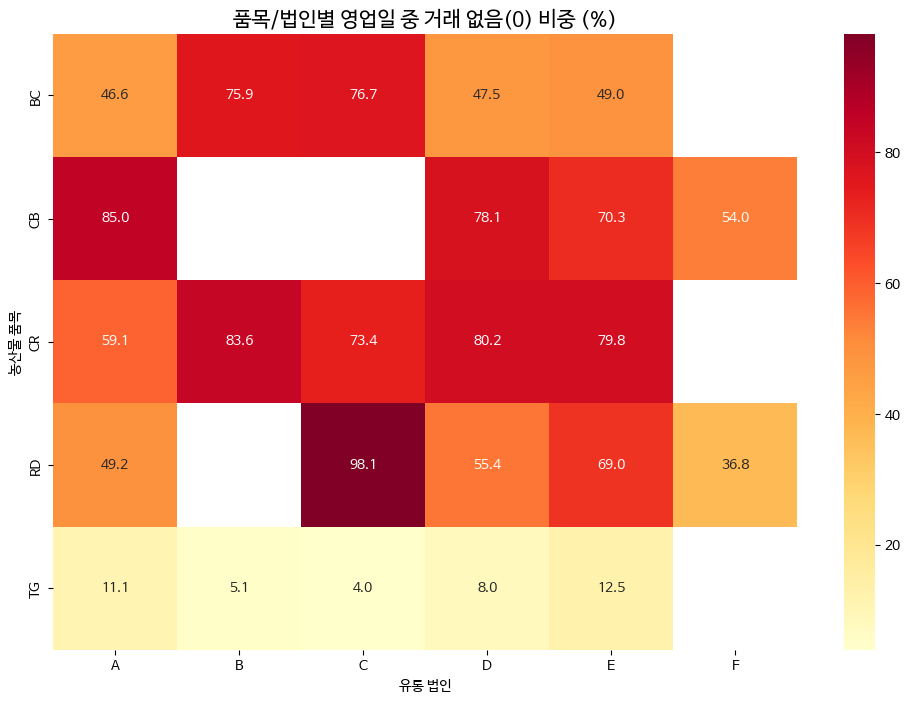

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# --- [폰트 설정] 시스템 내 한글 폰트 자동 탐색 ---
def set_korean_font():
    # 리눅스/코랩에서 주로 사용하는 나눔 폰트 탐색
    font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
    nanum_fonts = [f for f in font_list if 'Nanum' in f or 'Gothic' in f]
    
    if nanum_fonts:
        # 가장 첫 번째 찾은 한글 폰트 적용
        font_name = fm.FontProperties(fname=nanum_fonts[0]).get_name()
        plt.rc('font', family=font_name)
        print(f"설정된 폰트: {font_name}")
    else:
        # 폰트를 못 찾을 경우 기본 설정 (그래도 깨진다면 아래 설치 명령어 참고)
        plt.rc('font', family='DejaVu Sans')
        print("한글 폰트를 찾지 못했습니다. 시스템에 폰트 설치가 필요합니다.")
        
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

set_korean_font()

# 2. 데이터 로드 및 전처리
train = pd.read_csv('train.csv')
train['timestamp'] = pd.to_datetime(train['timestamp'])
train['day_name'] = train['timestamp'].dt.day_name()
train['is_zero'] = (train['price(원/kg)'] == 0) & (train['supply(kg)'] == 0)

# --- 시각화 1: 요일별 0 데이터 발생 확률 ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_analysis = train.groupby('day_name')['is_zero'].mean().reindex(day_order).reset_index()
dow_analysis['is_zero'] = dow_analysis['is_zero'] * 100

plt.figure(figsize=(10, 5))
# palette 경고 해결을 위해 hue와 legend 설정 추가
sns.barplot(data=dow_analysis, x='day_name', y='is_zero', hue='day_name', palette='coolwarm', legend=False)
plt.title('요일별 거래 없음(0) 발생 비율 (%)', fontsize=15)
plt.ylabel('비중 (%)')
plt.xlabel('요일')

for i, v in enumerate(dow_analysis['is_zero']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.show()

# --- 시각화 2: 날짜별 시장 휴장 추이 ---
daily_zero_ratio = train.groupby('timestamp')['is_zero'].mean()
plt.figure(figsize=(15, 5))
plt.plot(daily_zero_ratio.index, daily_zero_ratio.values, color='red', linewidth=0.5)
plt.title('날짜별 시장 휴장 추이 (1.0 = 전체 품목 거래 없음)', fontsize=15)
plt.axhline(y=1.0, color='gray', linestyle='--')
plt.show()

# --- 시각화 3: 품목/법인별 영업일 중 0 데이터 비중 (히트맵) ---
market_holidays = daily_zero_ratio[daily_zero_ratio == 1.0].index
working_days_df = train[~train['timestamp'].isin(market_holidays)]
item_corp_zeros = working_days_df.groupby(['item', 'corporation'])['is_zero'].mean().unstack() * 100

plt.figure(figsize=(12, 8))
sns.heatmap(item_corp_zeros, annot=True, fmt=".1f", cmap='YlOrRd')
plt.title('품목/법인별 영업일 중 거래 없음(0) 비중 (%)', fontsize=15)
plt.xlabel('유통 법인')
plt.ylabel('농산물 품목')
plt.show()

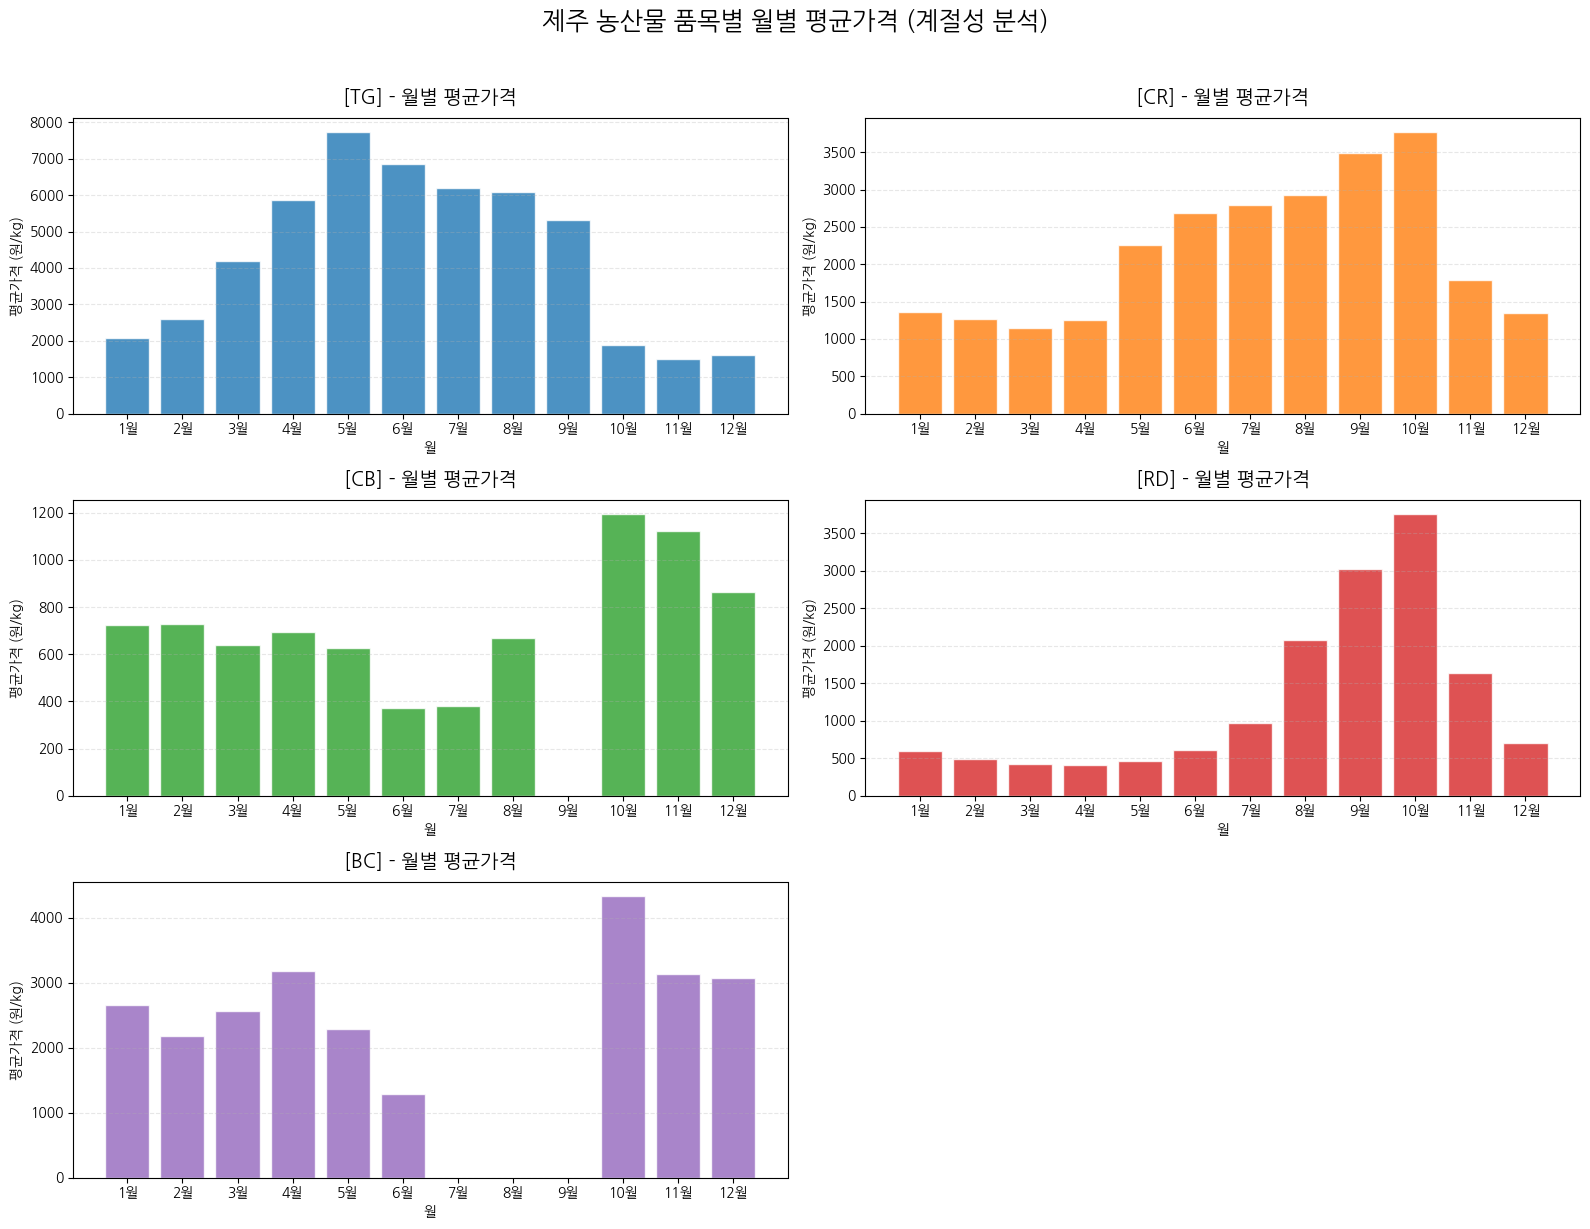

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 전처리 상태 확인 (컬럼명 및 month 생성)
if 'month' not in train_df.columns:
    train_df['month'] = train_df['timestamp'].dt.month

# 컬럼명 설정 (이전에 바꾼 이름에 맞춰 설정)
item_col = 'item'
target_col = 'price'  # 또는 'price(원/kg)'

# 2. 거래가 있는 데이터(0원 제외)만 필터링
df_plot = train_df[train_df[target_col] > 0].copy()

# 3. 시각화 설정
items = df_plot[item_col].unique()
n_items = len(items)
cols = 2
rows = (n_items + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

# 4. 품목별 반복문 실행
for i, item in enumerate(items):
    # 품목별 데이터 추출 및 월별 평균 계산
    df_item = df_plot[df_plot[item_col] == item]
    monthly = df_item.groupby('month')[target_col].mean()
    
    # 막대 그래프 그리기 (품목마다 다른 색상 적용)
    axes[i].bar(monthly.index, monthly.values, color=f'C{i}', alpha=0.8, edgecolor='white')
    
    # 그래프 디테일 설정
    axes[i].set_title(f'[{item}] - 월별 평균가격', fontsize=14, pad=10)
    axes[i].set_xlabel('월')
    axes[i].set_ylabel('평균가격 (원/kg)')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels([f'{m}월' for m in range(1, 13)], rotation=0)
    axes[i].grid(True, axis='y', alpha=0.3, linestyle='--')

# 사용하지 않는 빈 서브플롯은 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# 전체 제목 및 레이아웃 조정
plt.suptitle('제주 농산물 품목별 월별 평균가격 (계절성 분석)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

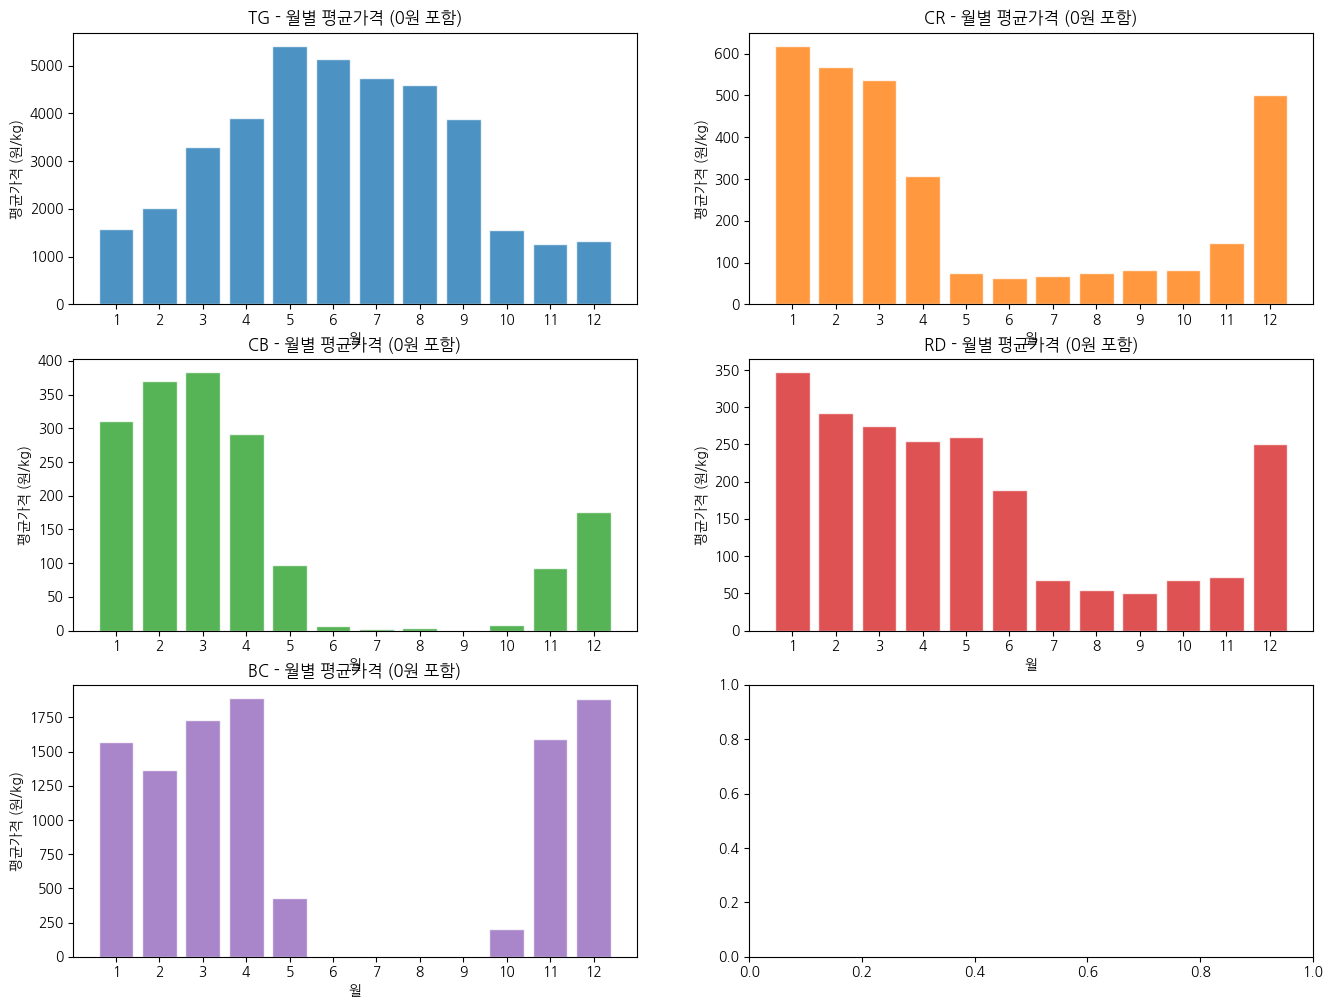

In [15]:
# 1. 전처리 확인 (month 컬럼이 없다면 생성)
if 'month' not in train_df.columns:
    train_df['month'] = train_df['timestamp'].dt.month

# 2. 변수 설정
date_col = 'timestamp'
item_col = 'item'
target_col = 'price'  # 컬럼명 확인 필요 (price 또는 price(원/kg))

# 3. 0원 데이터를 포함한 전체 데이터 사용
# (필터링 없이 train_df를 그대로 사용합니다)
train = train_df 

if date_col and target_col and 'month' in train.columns:
    month_labels = [f'{m}월' for m in range(1, 13)]

    if item_col:
        items = train[item_col].unique()
        n_items = len(items)
        cols = 2
        rows = (n_items + 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
        axes = axes.flatten()

        for i, item in enumerate(items):
            # 특정 품목의 전체 데이터(0원 포함) 추출
            df_item = train[train[item_col] == item]
            
            # 월별 평균 계산 (0원이 포함되므로 결과값이 낮아집니다)
            monthly = df_item.groupby('month')[target_col].mean()
            
            # 모든 달(1~12월)을 표시하기 위해 재색인
            monthly = monthly.reindex(range(1, 13), fill_value=0)
            
            axes[i].bar(monthly.index, monthly.values, color=f'C{i}', alpha=0.8, edgecolor='white')
            axes[i].set_title(f'{item} - 월별 평균가격 (0원 포함)', fontsize=12)
            axes[i].set_xlabel('월')
            axes[i].set_ylabel('평균가격 (원/kg)')
            axes[i].set_xticks(range(1, 13))
            axes[i].set_xticklabels

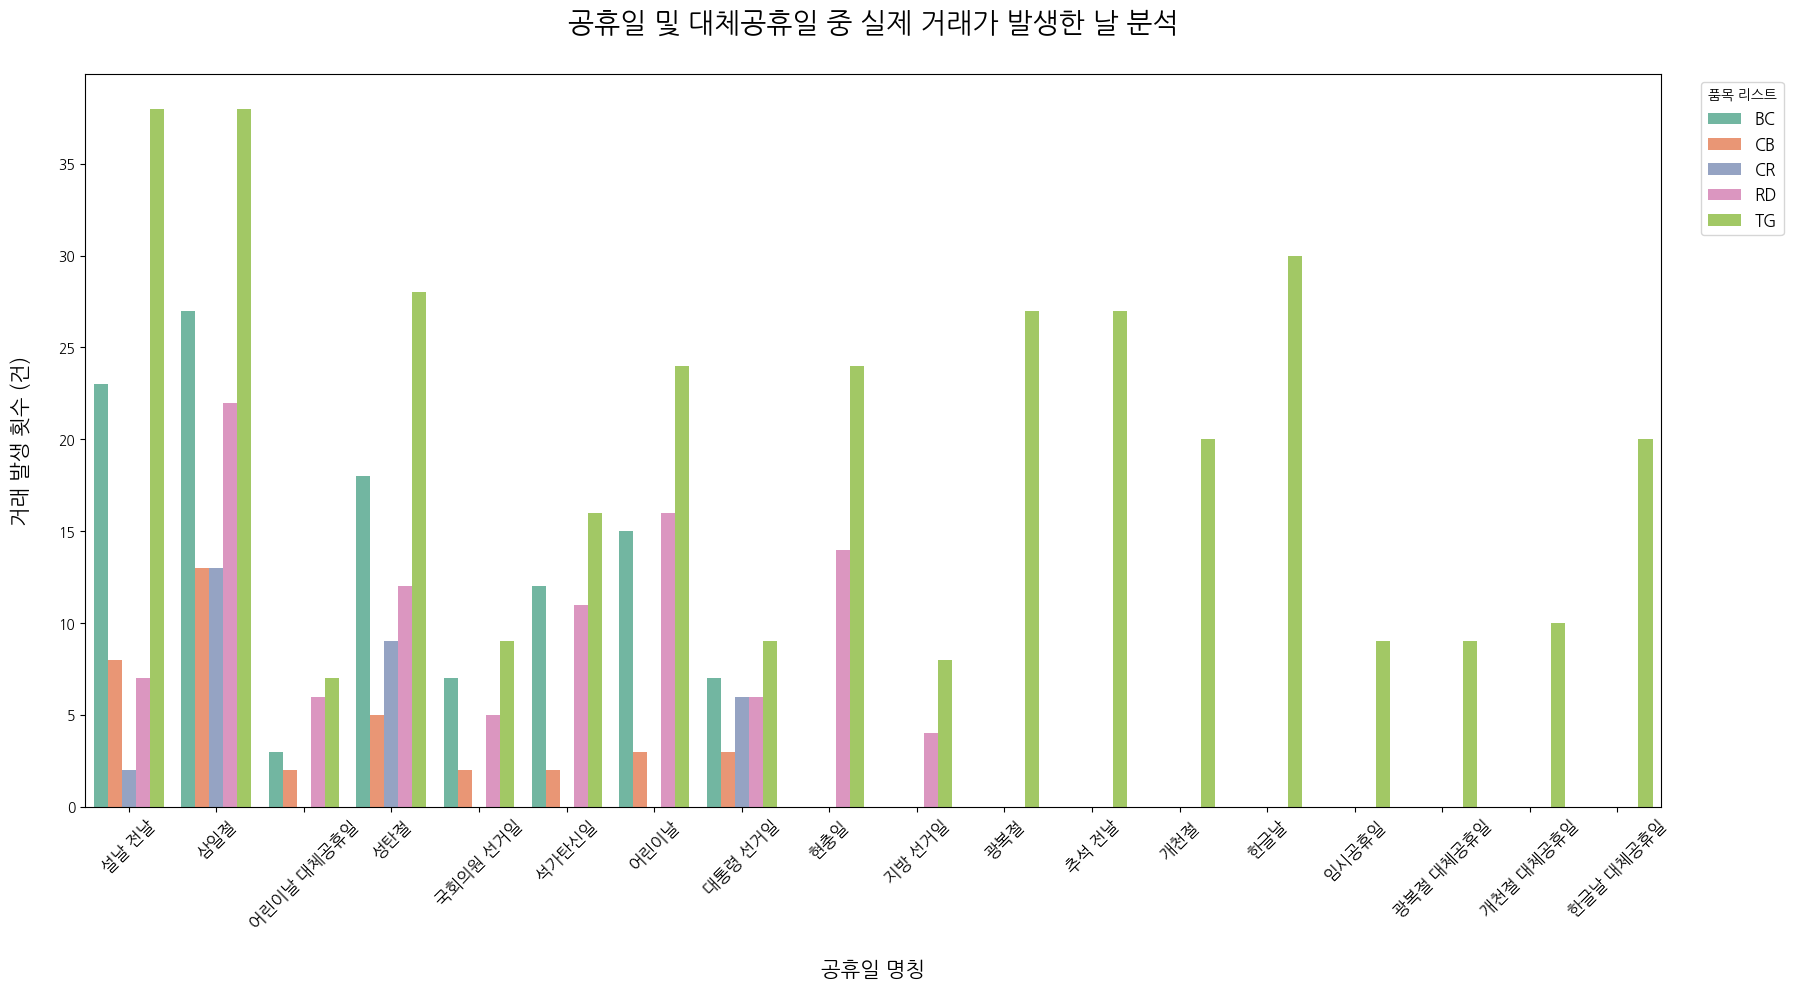

--- [공휴일 거래 상세 내역 (대체공휴일 포함)] ---


,날짜,공휴일명,품목,평균단가
0,2019-02-04,설날 전날,BC,2095.400000
1,2019-02-04,설날 전날,CB,261.500000
2,2019-02-04,설날 전날,RD,309.500000
3,2019-02-04,설날 전날,TG,2259.700000
4,2019-03-01,삼일절,BC,1997.571429
...,...,...,...,...
104,2023-03-01,삼일절,BC,3498.285714
105,2023-03-01,삼일절,CB,646.750000
106,2023-03-01,삼일절,CR,2031.750000
107,2023-03-01,삼일절,RD,585.800000


In [39]:
import pandas as pd
import holidays
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 공휴일 한글 매핑 딕셔너리 (이미지 속 영문 명칭 모두 포함)
holiday_ko = {
    # 신정
    "New Year's Day": "신정",
    
    # 설날 (표준 및 변이형 통합)
    "Lunar New Year's Day": "설날",
    "The day preceding Lunar New Year's Day": "설날 전날",
    "The day after Lunar New Year's Day": "설날 다음날",
    "Korean New Year's Day": "설날",
    "The day preceding Korean New Year's Day": "설날 전날",
    "The day after Korean New Year's Day": "설날 다음날",
    "The day preceding Korean New Year": "설날 전날", # 질문하신 명칭
    "The day after Korean New Year": "설날 다음날",
    
    # 삼일절 및 어린이날
    "Independence Movement Day": "삼일절",
    "Children's Day": "어린이날",
    
    # 부처님 오신 날 (표준 명칭 대응)
    "Buddha's Birthday": "석가탄신일",
    "Vesak": "석가탄신일",
    
    # 현충일, 제헌절, 광복절
    "Memorial Day": "현충일",
    "Constitution Day": "제헌절",
    "Liberation Day": "광복절",
    
    # 추석 (표준 및 변이형 통합)
    "Chuseok": "추석",
    "The day preceding Chuseok": "추석 전날",
    "The day after Chuseok": "추석 다음날",
    
    # 개천절, 한글날, 성탄절
    "National Foundation Day": "개천절",
    "Hangul Day": "한글날",
    "Christmas Day": "성탄절",
    
    # 선거일 (추가)
    "National Assembly Election Day": "국회의원 선거일",
    "Presidential Election Day": "대통령 선거일",
    "Local Election Day": "지방 선거일",
    
    # 대체 공휴일 (패턴 대응)
    "Alternative holiday for Children's Day": "어린이날 대체공휴일",
    "Alternative holiday for Buddha's Birthday": "석가탄신일 대체공휴일",
    "Alternative holiday for Lunar New Year's Day": "설날 대체공휴일",
    "Alternative holiday for Korean New Year's Day": "설날 대체공휴일",
    "Alternative holiday for Chuseok": "추석 대체공휴일",
    "Alternative holiday for Independence Movement Day": "삼일절 대체공휴일",
    "Alternative holiday for Liberation Day": "광복절 대체공휴일",
    "Alternative holiday for National Foundation Day": "개천절 대체공휴일",
    "Alternative holiday for Hangul Day": "한글날 대체공휴일",
    "Alternative holiday for Constitution Day": "제헌절 대체공휴일",
    "Temporary Public Holiday": "임시공휴일"
}

# 2. 데이터 필터링 및 컬럼 설정
start_date = '2019-01-01'
end_date = '2023-03-03'
p_col = 'price' if 'price' in train_df.columns else 'price(원/kg)'

mask = (train_df['timestamp'] >= start_date) & (train_df['timestamp'] <= end_date)
target_df = train_df.loc[mask].copy()

# 3. 공휴일 정보 생성 및 한글화 적용
kr_holidays = holidays.KR()
target_df['is_holiday'] = target_df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
target_df['holiday_en'] = target_df['timestamp'].apply(lambda x: kr_holidays.get(x))
target_df['공휴일_명칭'] = target_df['holiday_en'].map(holiday_ko).fillna(target_df['holiday_en'])

# 4. 공휴일 중 실제 거래 발생 데이터 추출
sold_on_holiday = target_df[(target_df['is_holiday'] == 1) & (target_df[p_col] > 0)].copy()

# 5. 시각화 (간격 및 한글화 최적화)
if not sold_on_holiday.empty:
    plt.figure(figsize=(18, 10))
    
    # 막대 그래프 생성
    sns.countplot(data=sold_on_holiday, x='공휴일_명칭', hue='item', palette='Set2')
    
    # 텍스트 간격(pad) 및 한글화 설정
    plt.title('공휴일 및 대체공휴일 중 실제 거래가 발생한 날 분석', fontsize=20, pad=30)
    plt.xlabel('공휴일 명칭', fontsize=15, labelpad=20)
    plt.ylabel('거래 발생 횟수 (건)', fontsize=15, labelpad=20)
    
    # X축 눈금 설정 (간격을 위해 45도 회전)
    plt.xticks(rotation=45, fontsize=12)
    
    # 범례 설정 (한글화 및 위치 조정)
    plt.legend(title='품목 리스트', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
    
    plt.tight_layout()
    plt.show()

    # 결과 요약 표 출력
    summary = sold_on_holiday.groupby(['timestamp', '공휴일_명칭', 'item'])[p_col].mean().reset_index()
    summary.columns = ['날짜', '공휴일명', '품목', '평균단가']
    print("--- [공휴일 거래 상세 내역 (대체공휴일 포함)] ---")
    display(summary)

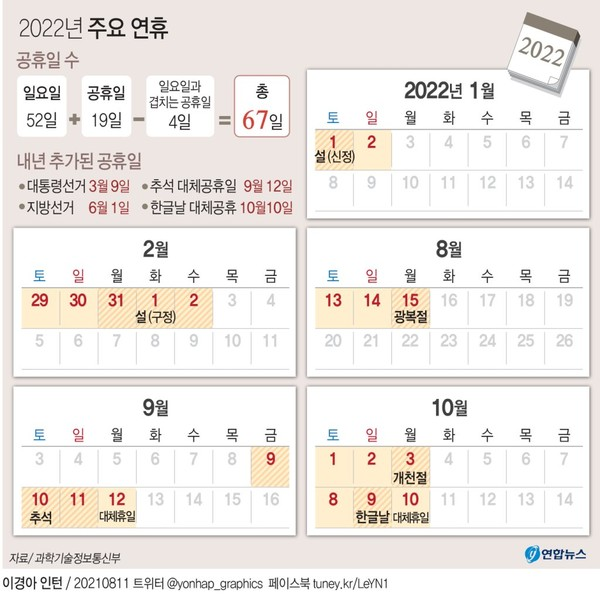

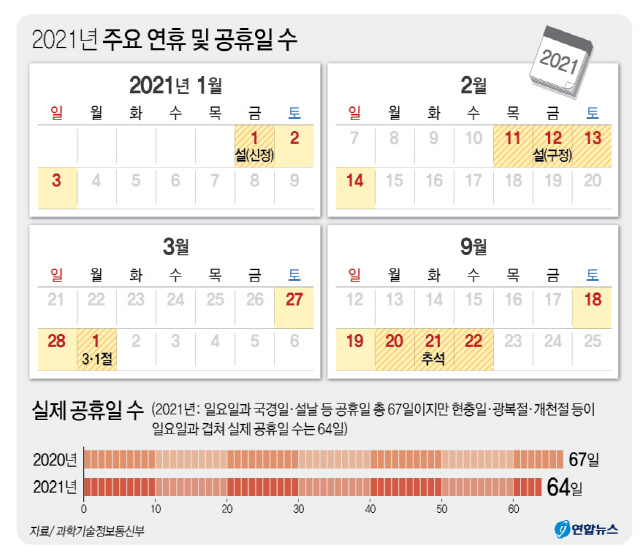

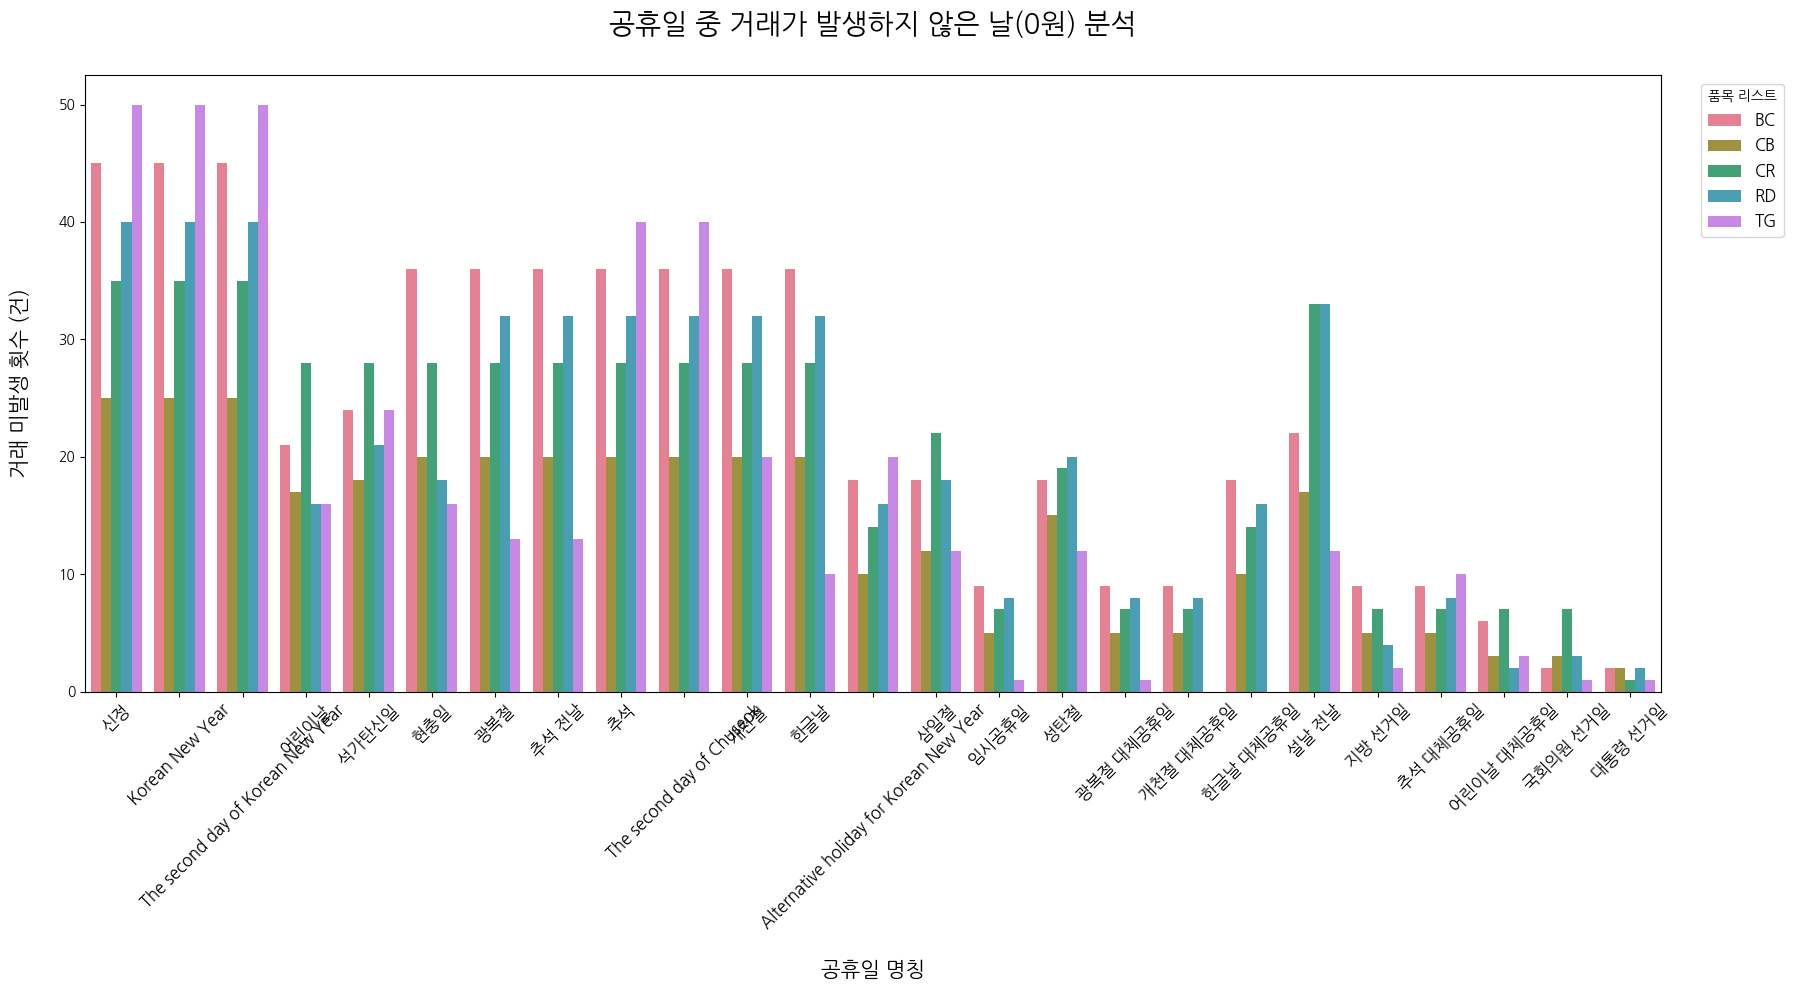

--- [거래 미발생 공휴일 상세 내역 (0원)] ---


,날짜,공휴일명,품목,데이터개수
0,2019-01-01,신정,BC,9
1,2019-01-01,신정,CB,5
2,2019-01-01,신정,CR,7
3,2019-01-01,신정,RD,8
4,2019-01-01,신정,TG,10
5,2019-02-04,설날 전날,BC,4
6,2019-02-04,설날 전날,CB,3
7,2019-02-04,설날 전날,CR,7
8,2019-02-04,설날 전날,RD,6
9,2019-02-05,Korean New Year,BC,9


In [40]:
# 4. "공휴일"이면서 "가격이 0원인(거래가 없는)" 데이터만 추출
# p_col 조건만 > 0 에서 == 0 으로 변경합니다.
no_trade_on_holiday = target_df[
    (target_df['is_holiday'] == 1) & 
    (target_df[p_col] == 0)
].copy()

# 5. 시각화 (거래 없는 공휴일 분석)
if not no_trade_on_holiday.empty:
    plt.figure(figsize=(18, 10))
    
    # 막대 그래프 생성 (거래가 없었던 횟수 카운트)
    sns.countplot(data=no_trade_on_holiday, x='공휴일_명칭', hue='item', palette='husl')
    
    plt.title('공휴일 중 거래가 발생하지 않은 날(0원) 분석', fontsize=20, pad=30)
    plt.xlabel('공휴일 명칭', fontsize=15, labelpad=20)
    plt.ylabel('거래 미발생 횟수 (건)', fontsize=15, labelpad=20)
    
    plt.xticks(rotation=45, fontsize=12)
    plt.legend(title='품목 리스트', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
    
    plt.tight_layout()
    plt.show()

    # 결과 요약 표 출력 (거래가 없었던 날짜 리스트)
    # 0원인 날의 평균을 내면 결과가 0이므로, 여기서는 날짜별 품목 리스트만 보여줍니다.
    summary_no_trade = no_trade_on_holiday.groupby(['timestamp', '공휴일_명칭', 'item']).size().reset_index()
    summary_no_trade.columns = ['날짜', '공휴일명', '품목', '데이터개수']
    print("--- [거래 미발생 공휴일 상세 내역 (0원)] ---")
    display(summary_no_trade.head(20)) # 너무 많을 수 있으니 상위 20개만 출력
else:
    print("분석 범위 내 모든 공휴일에 거래가 발생했습니다.")

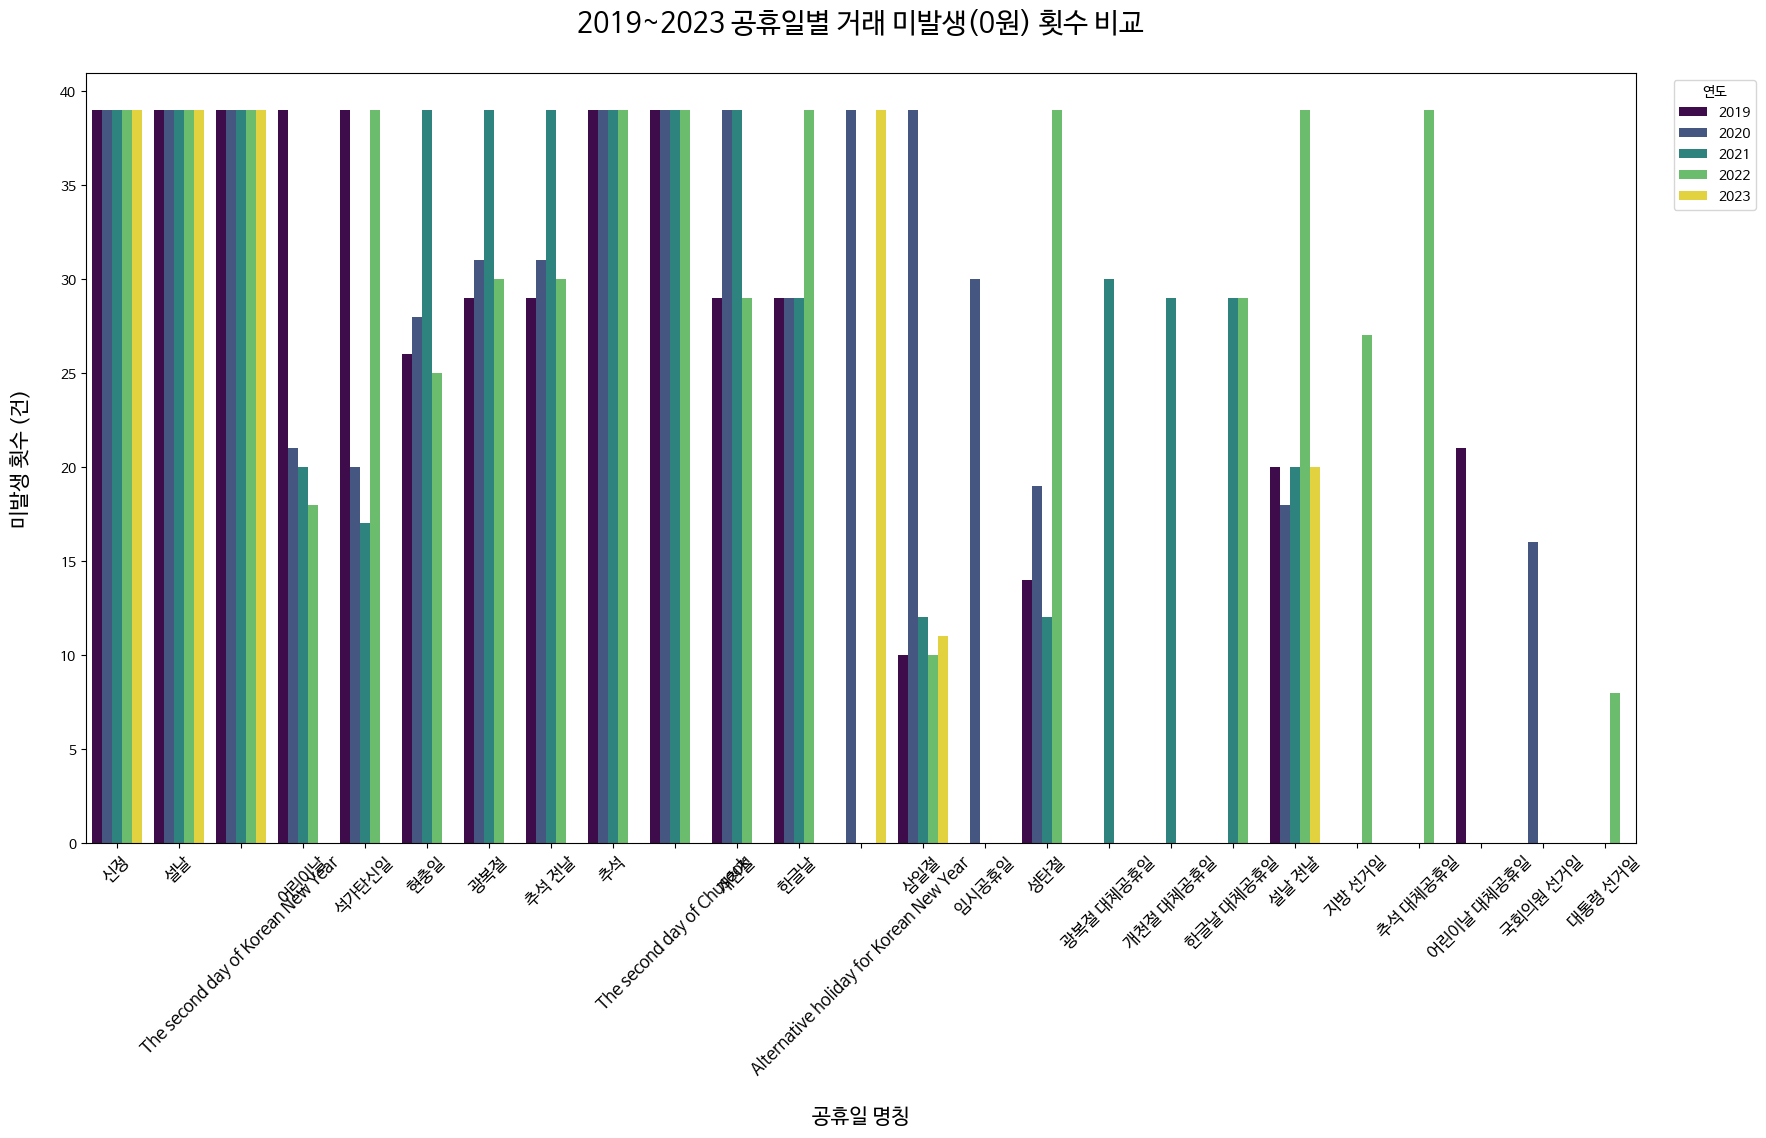

In [48]:
import pandas as pd
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. 공휴일 한글 매핑 딕셔너리 (생략 없이 최신화)
holiday_ko = {
    # 신정
    "New Year's Day": "신정",
    
    # 설날 (표준 및 변이형 통합)
    "Lunar New Year's Day": "설날",
    "The day preceding Lunar New Year's Day": "설날 전날",
    "The day after Lunar New Year's Day": "설날 다음날",
    "Korean New Year": "설날",
    "The day preceding Korean New Year's Day": "설날 전날",
    "The day after Korean New Year's Day": "설날 다음날",
    "The day preceding Korean New Year": "설날 전날", # 질문하신 명칭
    "The day after Korean New Year": "설날 다음날",
    
    # 삼일절 및 어린이날
    "Independence Movement Day": "삼일절",
    "Children's Day": "어린이날",
    
    # 부처님 오신 날 (표준 명칭 대응)
    "Buddha's Birthday": "석가탄신일",
    "Vesak": "석가탄신일",
    
    # 현충일, 제헌절, 광복절
    "Memorial Day": "현충일",
    "Constitution Day": "제헌절",
    "Liberation Day": "광복절",
    
    # 추석 (표준 및 변이형 통합)
    "Chuseok": "추석",
    "The day preceding Chuseok": "추석 전날",
    "The day after Chuseok": "추석 다음날",
    
    # 개천절, 한글날, 성탄절
    "National Foundation Day": "개천절",
    "Hangul Day": "한글날",
    "Christmas Day": "성탄절",
    
    # 선거일 (추가)
    "National Assembly Election Day": "국회의원 선거일",
    "Presidential Election Day": "대통령 선거일",
    "Local Election Day": "지방 선거일",
    
    # 대체 공휴일 (패턴 대응)
    "Alternative holiday for Children's Day": "어린이날 대체공휴일",
    "Alternative holiday for Buddha's Birthday": "석가탄신일 대체공휴일",
    "Alternative holiday for Lunar New Year's Day": "설날 대체공휴일",
    "Alternative holiday for Korean New Year's Day": "설날 대체공휴일",
    "Alternative holiday for Chuseok": "추석 대체공휴일",
    "Alternative holiday for Independence Movement Day": "삼일절 대체공휴일",
    "Alternative holiday for Liberation Day": "광복절 대체공휴일",
    "Alternative holiday for National Foundation Day": "개천절 대체공휴일",
    "Alternative holiday for Hangul Day": "한글날 대체공휴일",
    "Alternative holiday for Constitution Day": "제헌절 대체공휴일",
    "Temporary Public Holiday": "임시공휴일"
}

# 2. 분석 범위 설정 (2019년부터 2023년 전체 데이터)
# 이 부분이 2019년으로 되어 있는지 확인해 보세요!
start_date = '2019-01-01'
end_date = '2023-03-03'
p_col = 'price' if 'price' in train_df.columns else 'price(원/kg)'

# 3. 데이터 필터링
mask = (train_df['timestamp'] >= start_date) & (train_df['timestamp'] <= end_date)
target_df = train_df.loc[mask].copy()

# 4. 공휴일 정보 매핑
kr_holidays = holidays.KR()
target_df['is_holiday'] = target_df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
target_df['holiday_en'] = target_df['timestamp'].apply(lambda x: kr_holidays.get(x))
target_df['공휴일_명칭'] = target_df['holiday_en'].map(holiday_ko).fillna(target_df['holiday_en'])

# 5. 거래 미발생(0원) 공휴일 추출
no_trade_on_holiday = target_df[(target_df['is_holiday'] == 1) & (target_df[p_col] == 0)].copy()

# 6. 시각화 (전체 기간이 잘 보이도록 설정)
if not no_trade_on_holiday.empty:
    plt.figure(figsize=(20, 10))
    
    # x축을 '연도별' 공휴일 발생 횟수로 시각화하려면 countplot을 사용
    # 연도 정보를 추가해서 연도별로 비교해 보겠습니다.
    no_trade_on_holiday['year'] = no_trade_on_holiday['timestamp'].dt.year
    
    sns.countplot(data=no_trade_on_holiday, x='공휴일_명칭', hue='year', palette='viridis')
    
    plt.title('2019~2023 공휴일별 거래 미발생(0원) 횟수 비교', fontsize=20, pad=30)
    plt.xlabel('공휴일 명칭', fontsize=15, labelpad=20)
    plt.ylabel('미발생 횟수 (건)', fontsize=15, labelpad=20)
    
    plt.xticks(rotation=45, fontsize=12)
    plt.legend(title='연도', bbox_to_anchor=(1.02, 1), loc='upper left')

In [43]:
import pandas as pd
import holidays

# 1. 공휴일 한글 매핑 딕셔너리
holiday_ko = {
    # 신정
    "New Year's Day": "신정",
    
    # 설날 (표준 및 변이형 통합)
    "Lunar New Year's Day": "설날",
    "The day preceding Lunar New Year's Day": "설날 전날",
    "The day after Lunar New Year's Day": "설날 다음날",
    "Korean New Year's Day": "설날",
    "The day preceding Korean New Year's Day": "설날 전날",
    "The day after Korean New Year's Day": "설날 다음날",
    "The day preceding Korean New Year": "설날 전날", # 질문하신 명칭
    "The day after Korean New Year": "설날 다음날",
    
    # 삼일절 및 어린이날
    "Independence Movement Day": "삼일절",
    "Children's Day": "어린이날",
    
    # 부처님 오신 날 (표준 명칭 대응)
    "Buddha's Birthday": "석가탄신일",
    "Vesak": "석가탄신일",
    
    # 현충일, 제헌절, 광복절
    "Memorial Day": "현충일",
    "Constitution Day": "제헌절",
    "Liberation Day": "광복절",
    
    # 추석 (표준 및 변이형 통합)
    "Chuseok": "추석",
    "The day preceding Chuseok": "추석 전날",
    "The day after Chuseok": "추석 다음날",
    
    # 개천절, 한글날, 성탄절
    "National Foundation Day": "개천절",
    "Hangul Day": "한글날",
    "Christmas Day": "성탄절",
    
    # 선거일 (추가)
    "National Assembly Election Day": "국회의원 선거일",
    "Presidential Election Day": "대통령 선거일",
    "Local Election Day": "지방 선거일",
    
    # 대체 공휴일 (패턴 대응)
    "Alternative holiday for Children's Day": "어린이날 대체공휴일",
    "Alternative holiday for Buddha's Birthday": "석가탄신일 대체공휴일",
    "Alternative holiday for Lunar New Year's Day": "설날 대체공휴일",
    "Alternative holiday for Korean New Year's Day": "설날 대체공휴일",
    "Alternative holiday for Chuseok": "추석 대체공휴일",
    "Alternative holiday for Independence Movement Day": "삼일절 대체공휴일",
    "Alternative holiday for Liberation Day": "광복절 대체공휴일",
    "Alternative holiday for National Foundation Day": "개천절 대체공휴일",
    "Alternative holiday for Hangul Day": "한글날 대체공휴일",
    "Alternative holiday for Constitution Day": "제헌절 대체공휴일",
    "Temporary Public Holiday": "임시공휴일"
}

# 2. 분석 범위 및 데이터 필터링 (2019 ~ 2023 전체)
start_date = '2019-01-01'
end_date = '2023-03-03'
p_col = 'price' if 'price' in train_df.columns else 'price(원/kg)'

target_df = train_df[(train_df['timestamp'] >= start_date) & (train_df['timestamp'] <= end_date)].copy()

# 3. 공휴일 정보 및 연도 추출
kr_holidays = holidays.KR()
target_df['is_holiday'] = target_df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
target_df['holiday_en'] = target_df['timestamp'].apply(lambda x: kr_holidays.get(x))
target_df['공휴일명'] = target_df['holiday_en'].map(holiday_ko).fillna(target_df['holiday_en'])
target_df['연도'] = target_df['timestamp'].dt.year

# 4. 거래 미발생(0원) 공휴일 데이터만 추출
no_trade_df = target_df[(target_df['is_holiday'] == 1) & (target_df[p_col] == 0)]

# 5. 데이터프레임 요약 (연도별/공휴일별 거래 미발생 건수)
# 품목이 여러 개이므로, 각 공휴일에 몇 개의 품목 데이터가 0원이었는지 보여줍니다.
summary_df = no_trade_df.groupby(['연도', '공휴일명']).size().unstack(fill_value=0)

print(f"📊 {start_date} ~ {end_date} 거래 미발생 공휴일 현황")
display(summary_df)

# (옵션) 상세 날짜별로 보고 싶다면 아래 코드를 실행하세요.
# trade_dates = no_trade_df[['timestamp', '공휴일명', 'item']].drop_duplicates().sort_values('timestamp')
# display(trade_dates)

📊 2019-01-01 ~ 2023-03-03 거래 미발생 공휴일 현황


공휴일명,Alternative holiday for Korean New Year,Korean New Year,The second day of Chuseok,The second day of Korean New Year,개천절,개천절 대체공휴일,광복절,광복절 대체공휴일,국회의원 선거일,대통령 선거일,...,어린이날,어린이날 대체공휴일,임시공휴일,지방 선거일,추석,추석 대체공휴일,추석 전날,한글날,한글날 대체공휴일,현충일
연도,,,,,,,,,,,,,,,,,,,,,
2019,0,39,39,39,29,0,29,0,0,0,...,39,21,0,0,39,0,29,29,0,26
2020,39,39,39,39,39,0,31,0,16,0,...,21,0,30,0,39,0,31,29,0,28
2021,0,39,39,39,39,29,39,30,0,0,...,20,0,0,0,39,0,39,29,29,39
2022,0,39,39,39,29,0,30,0,0,8,...,18,0,0,27,39,39,30,39,29,25
2023,39,39,0,39,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 데이터 컬럼명 변환 및 기본 전처리
모델링과 분석의 편의를 위해 컬럼명을 단순화하고, 시계열 분석에 필수적인 날짜 피처(연, 월, 일, 요일)를 생성합니다.

In [17]:
# 1. 데이터 로드 (변수명을 train_df로 통일합니다)
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. 컬럼명 변환 (한글/단위 제거)
# train 데이터 변환
train_df.rename(columns={
    'supply(kg)': 'supply',
    'price(원/kg)': 'price'
}, inplace=True)

# 3. 날짜 데이터 형식 변환 (String -> Datetime)
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])

# 4. 날짜 파생 변수 생성 (EDA와 모델링에 모두 사용됨)
def add_date_features(df):
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['day'] = df['timestamp'].dt.day
    df['dow'] = df['timestamp'].dt.dayofweek # 0:월, 6:일
    df['day_name'] = df['timestamp'].dt.day_name()
    return df

train_df = add_date_features(train_df)
test_df = add_date_features(test_df)

print("✅ 컬럼명 변환 및 날짜 피처 생성 완료!")
print(f"변환된 컬럼명: {train_df.columns.tolist()}")
display(train_df.head(3))

✅ 컬럼명 변환 및 날짜 피처 생성 완료!
변환된 컬럼명: ['ID', 'timestamp', 'item', 'corporation', 'location', 'supply', 'price', 'year', 'month', 'day', 'dow', 'day_name']


,ID,timestamp,item,corporation,location,supply,price,year,month,day,dow,day_name
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0,2019,1,1,1,Tuesday
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0,2019,1,2,2,Wednesday
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0,2019,1,3,3,Thursday


In [18]:
# 1. 수출입 데이터 로드
trade = pd.read_csv('international_trade.csv')

# 2. 기간을 연/월로 분리하여 병합 준비
trade['year'] = trade['기간'].apply(lambda x: int(x.split('-')[0]))
trade['month'] = trade['기간'].apply(lambda x: int(x.split('-')[1]))

# 3. 품목명 매칭 (수출입 데이터의 이름을 train 데이터와 일치시킴)
# 주의: 브로콜리는 이름이 다르므로 매칭 작업이 필요함
trade_item_map = {
    '감귤': 'TG', '당근': 'CR', '양배추': 'CB', '무': 'RD', 
    '꽃양배추와 브로콜리(broccoli)': 'BC'
}
trade['item'] = trade['품목명'].map(trade_item_map)

# 4. 월별 수입 중량 합계 계산 후 train 데이터와 결합
trade_monthly = trade.groupby(['year', 'month', 'item'])['수입 중량'].sum().reset_index()
train_with_trade = pd.merge(train_df, trade_monthly, on=['year', 'month', 'item'], how='left')

print("✅ 수출입 데이터 결합 완료 (수입 중량 컬럼 추가)")
display(train_with_trade[['timestamp', 'item', 'price', '수입 중량']].dropna().head())

✅ 수출입 데이터 결합 완료 (수입 중량 컬럼 추가)


,timestamp,item,price,수입 중량
0,2019-01-01,TG,0.0,0.0
1,2019-01-02,TG,0.0,0.0
2,2019-01-03,TG,1728.0,0.0
3,2019-01-04,TG,1408.0,0.0
4,2019-01-05,TG,1250.0,0.0


## 8. 시차 변수(Lag Features) 생성
과거의 가격 정보를 현재 시점의 변수로 사용하여 모델이 '추세'를 학습할 수 있게 합니다.

In [19]:
# 품목/법인/지역별로 정렬한 뒤 시차 변수 생성
train_df = train_df.sort_values(['item', 'corporation', 'location', 'timestamp'])

# 1일 전 가격, 7일 전 가격, 7일 평균 가격 생성
group_cols = ['item', 'corporation', 'location']
train_df['price_lag_1'] = train_df.groupby(group_cols)['price'].shift(1)
train_df['price_lag_7'] = train_df.groupby(group_cols)['price'].shift(7)
train_df['price_7d_mean'] = train_df.groupby(group_cols)['price'].transform(lambda x: x.rolling(window=7).mean())

print("✅ 시차 변수(Lag 1, Lag 7, 7d Mean) 생성 완료")
display(train_df[['timestamp', 'item', 'price', 'price_lag_1', 'price_7d_mean']].tail())

✅ 시차 변수(Lag 1, Lag 7, 7d Mean) 생성 완료


,timestamp,item,price,price_lag_1,price_7d_mean
15225,2023-02-27,TG,3418.0,0.0,2719.571429
15226,2023-02-28,TG,3141.0,3418.0,2754.285714
15227,2023-03-01,TG,4235.0,3141.0,2873.571429
15228,2023-03-02,TG,3960.0,4235.0,2960.857143
15229,2023-03-03,TG,3791.0,3960.0,3070.142857


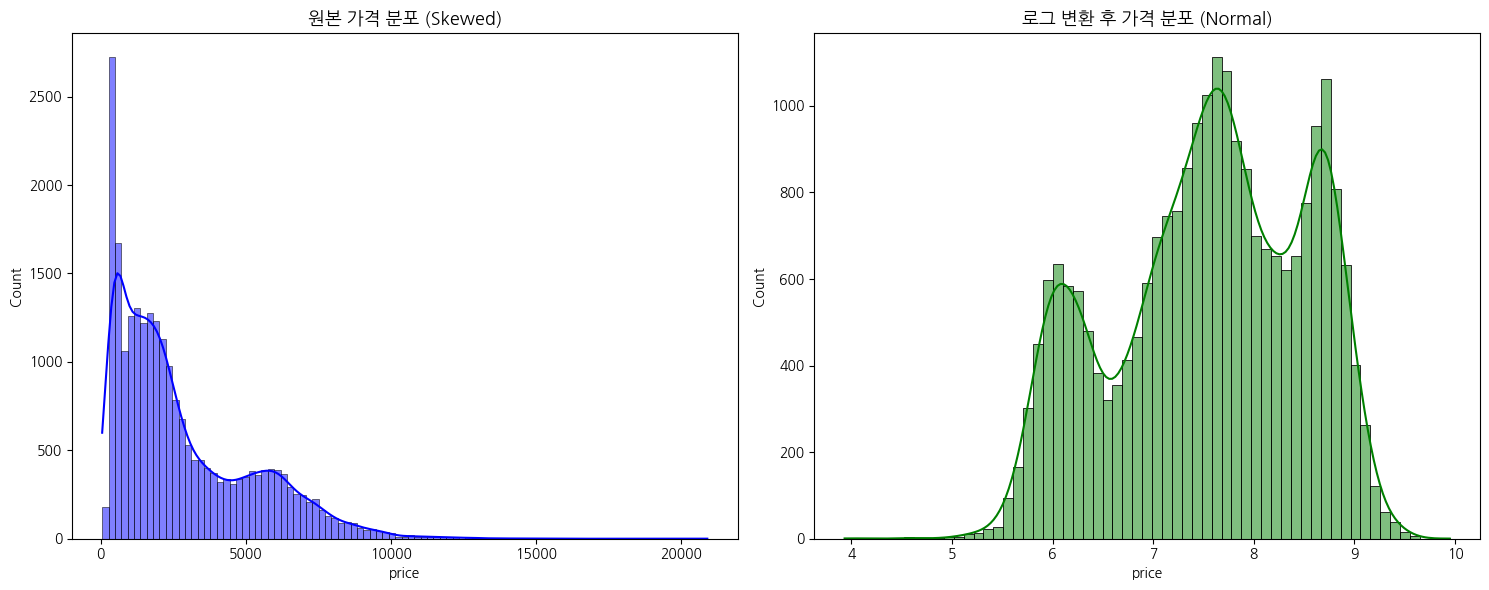

💡 인사이트: 로그 변환 시 데이터의 왜도(Skewness)가 줄어들어 모델이 훨씬 더 잘 학습할 수 있는 환경이 됩니다.


In [20]:
# 1. 로그 변환 시각화 비교
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(train_df[train_df['price'] > 0]['price'], kde=True, color='blue')
plt.title('원본 가격 분포 (Skewed)', fontsize=13)

plt.subplot(1, 2, 2)
# 0원 데이터는 로그를 취할 수 없으므로 1을 더해줌 (np.log1p)
sns.histplot(np.log1p(train_df[train_df['price'] > 0]['price']), kde=True, color='green')
plt.title('로그 변환 후 가격 분포 (Normal)', fontsize=13)

plt.tight_layout()
plt.show()

print("💡 인사이트: 로그 변환 시 데이터의 왜도(Skewness)가 줄어들어 모델이 훨씬 더 잘 학습할 수 있는 환경이 됩니다.")